## SHAP Interpretation (Top 5 features)

In [1]:
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X_train, X_test, y_train, y_test = joblib.load("../data/processed/train_test_split.pkl")
final_model = joblib.load("../models/final_model.pkl")
preprocessor = joblib.load("../models/preprocessor.pkl")
feature_names = preprocessor.get_feature_names_out()

In [3]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

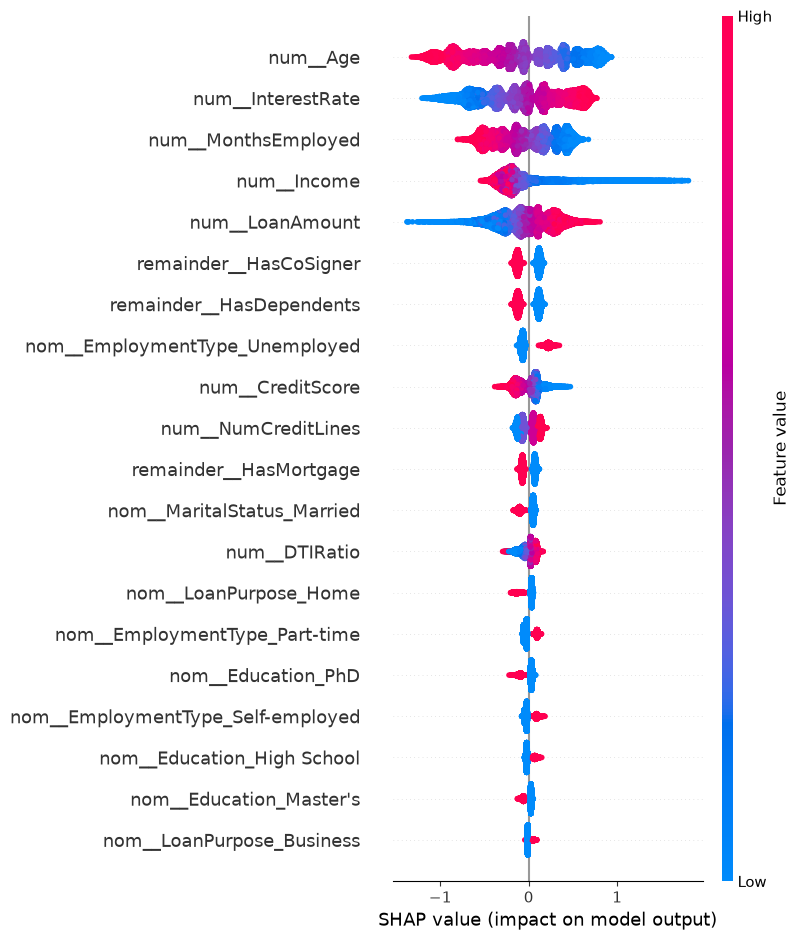

In [4]:
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

#### Top 5 features based on mean absolute SHAP value

In [5]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

print(shap_importance.head(5))

               feature  mean_abs_shap
0             num__Age       0.516525
6    num__InterestRate       0.398986
4  num__MonthsEmployed       0.293829
1          num__Income       0.272837
2      num__LoanAmount       0.241346


### SHAP Interpretation – Loan Default Risk Drivers

- **Credit Score**: Lower scores strongly increase default risk, consistent with EDA showing defaults clustered among borrowers with weaker credit histories.  
- **Income**: Higher income reduces default likelihood, matching the trend that financially stable borrowers manage repayments better.  
- **Loan Amount**: Larger loan sizes push risk upward, as bigger obligations strain repayment capacity.  
- **Employment Length**: Shorter tenure correlates with higher risk, reflecting job instability seen in defaults during EDA.  
- **Debt-to-Income Ratio (DTI)**: High DTI sharply raises default probability, confirming that over-leveraged borrowers are most vulnerable.  
- **Age**: Younger borrowers show slightly higher risk, aligning with EDA where defaults were more frequent among early-career individuals.  
- **Past Defaults / Delinquencies**: Prior negative credit events are strong predictors of future default, reinforcing historical patterns.  
- **Loan Purpose**: Risk varies by purpose -- e.g., personal loans showed higher default rates than mortgages in EDA.  
- **Interest Rate**: Higher rates increase risk, as costly loans are harder to sustain.  
- **Collateral / Security**: Presence of collateral lowers risk, consistent with EDA showing secured loans default less often.
